In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [4]:
df=pd.read_excel("Online Retail.xlsx")
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [11]:
#removing missing customer ids
df=df.dropna(subset=["CustomerID"])


In [13]:
#removing cancelled invoices
df=df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [15]:
#REMOVING INVALID QUANTITIES AND PRICES
df=df[df["Quantity"]>0]
df=df[df["UnitPrice"] >0]

In [17]:
#creating total amount
df["TotalAmount"]=df["Quantity"]* df["UnitPrice"]

In [19]:
print(df.shape)
print(df.head())

(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [26]:
#creating customer level data
customer_data=df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount","sum"),
    TotalQuantity=("Quantity" , "sum"),
    NumberOfTransactions=("InvoiceNo","nunique"),
    NumberOfProducts=("StockCode","nunique"),
    AverageOrderValue=("TotalAmount","mean"),
    Country=("Country","first")
).reset_index()
print(customer_data.head())


   CustomerID  TotalSpend  TotalQuantity  NumberOfTransactions  \
0     12346.0    77183.60          74215                     1   
1     12347.0     4310.00           2458                     7   
2     12348.0     1797.24           2341                     4   
3     12349.0     1757.55            631                     1   
4     12350.0      334.40            197                     1   

   NumberOfProducts  AverageOrderValue         Country  
0                 1       77183.600000  United Kingdom  
1               103          23.681319         Iceland  
2                22          57.975484         Finland  
3                73          24.076027           Italy  
4                17          19.670588          Norway  


In [29]:
#the target variable is:segment with three possible classes
customer_data["Segment"]=pd.qcut(
    customer_data["TotalSpend"],q=3,labels=["Low Value","Medium Value"," High Value"])
print(customer_data["Segment"].value_counts())

Segment
Low Value       1446
Medium Value    1446
 High Value     1446
Name: count, dtype: int64


In [31]:
features = [
    "TotalQuantity",
    "NumberOfTransactions",
    "NumberOfProducts",
    "AverageOrderValue"
]
X= customer_data[features]
y=customer_data["Segment"]

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [36]:
id3_model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)
id3_model.fit(X_train,y_train)
y_pred=id3_model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
['Low Value' 'Low Value' 'Low Value' 'Low Value' 'Medium Value'
 'Low Value' 'Low Value' ' High Value' 'Low Value' 'Medium Value'
 'Low Value' 'Medium Value' ' High Value' ' High Value' ' High Value'
 ' High Value' 'Low Value' 'Low Value' ' High Value' 'Low Value']


In [38]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nClassificationReport:")
print(classification_report(y_test,y_pred))

Accuracy: 0.8467741935483871

ClassificationReport:
              precision    recall  f1-score   support

  High Value       0.93      0.87      0.90       289
   Low Value       0.87      0.85      0.86       289
Medium Value       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868



In [42]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))


Confusion Matrix:
[[251   2  36]
 [  0 247  42]
 [ 19  34 237]]


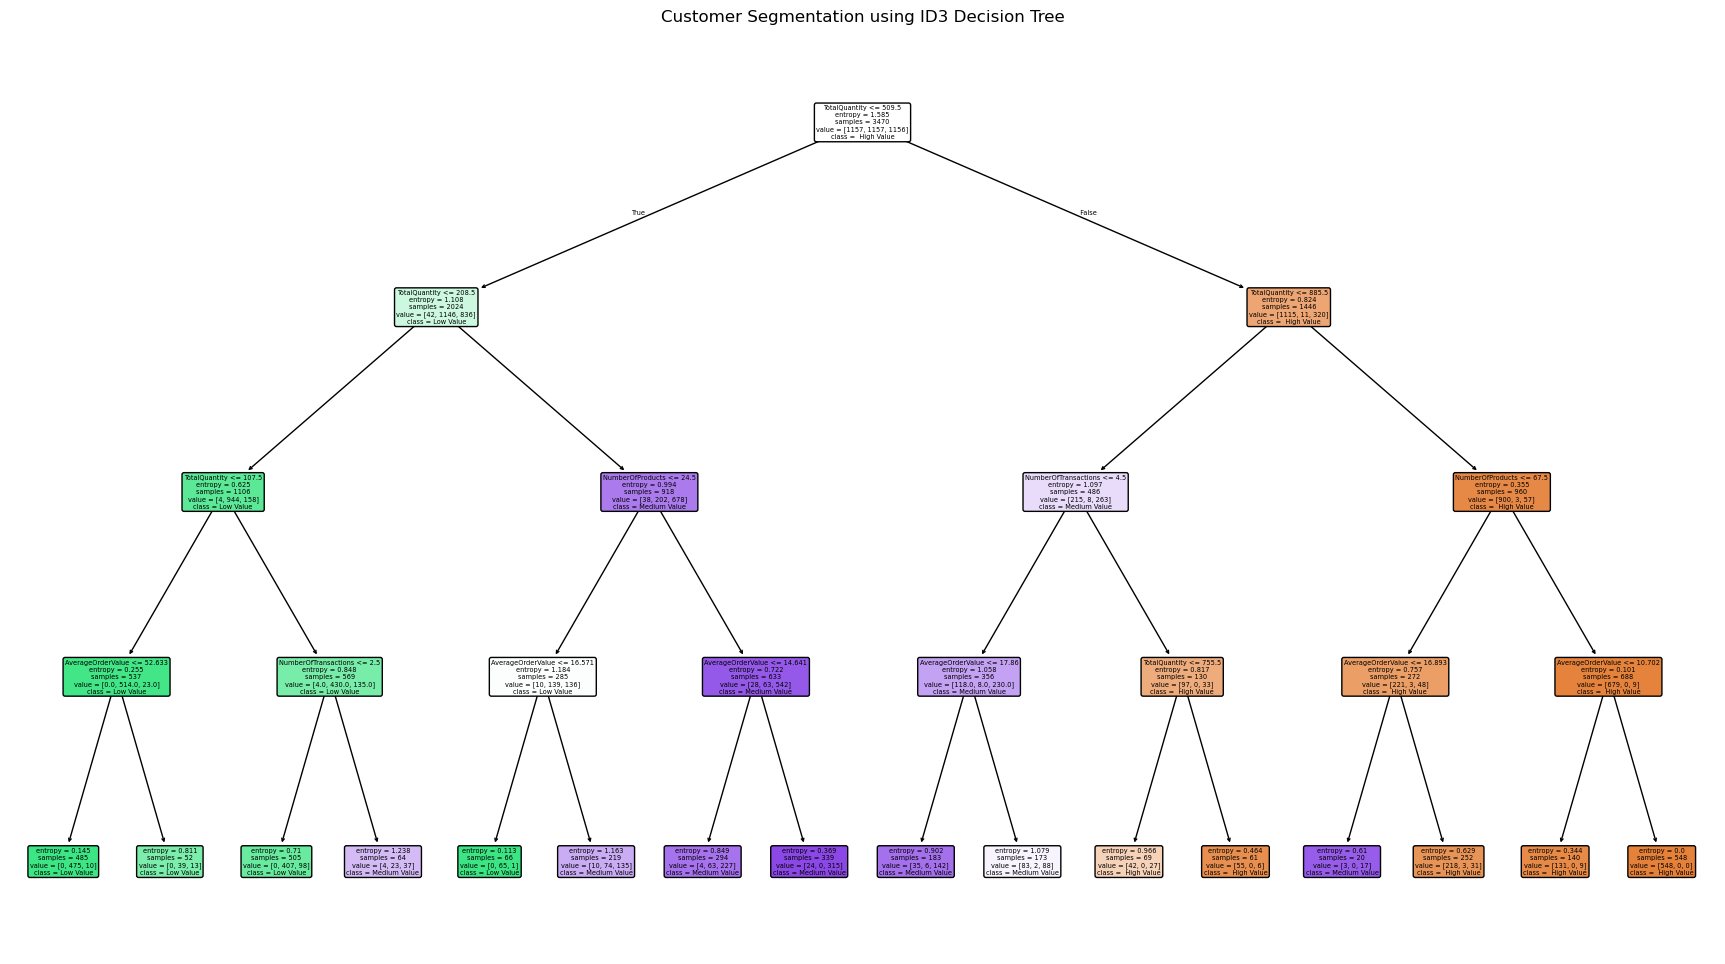

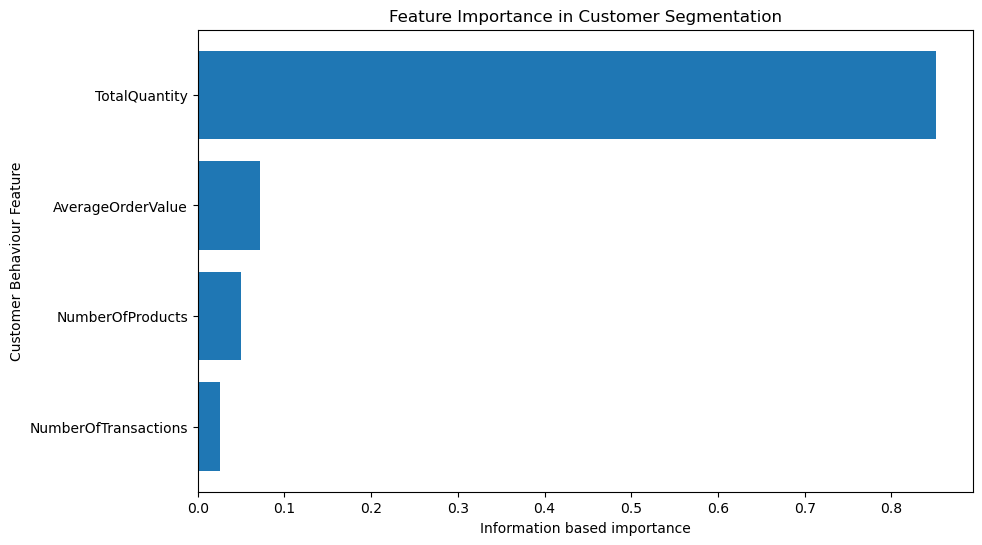

In [47]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance":id3_model.feature_importances_})
importance_sorted=importance.sort_values("Importance",ascending=True)
#decision tree
plt.figure(figsize=(22,12))
plot_tree(id3_model,feature_names=features,class_names=id3_model.classes_,filled=True,rounded=True,
    proportion=False)
plt.title("Customer Segmentation using ID3 Decision Tree")
plt.show()

#feature importance
plt.figure(figsize=(10,6))
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["Importance"]
)
plt.xlabel("Information based importance")
plt.ylabel("Customer Behaviour Feature")
plt.title("Feature Importance in Customer Segmentation")
plt.show()

